In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
# import loglike
# import modeselector
# import parismc
# import gc
# import pickle
import dynesty
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

#Generating data (true)

# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0 #NOTE: fixed
dist = 3 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #NOTE: fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # NOTE: fixed
Phi_r0 = 0.5

print('Generating data signal...')
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
print('Done generating data signal.')


print('Setting up GWFuncs...')
gwf = GWfuncs.GravWaveAnalysis(T, dt)
print('Done setting up GWFuncs.')


Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Generating data signal...
Done generating data signal.
Setting up GWFuncs...
Done setting up GWFuncs.


In [2]:
def loglike(params):
    m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0 = params
    phiK = phiS + np.pi/3

    try:
        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                                Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
                
        res = data - htemp
        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        log_like = -0.5 * inner_res.get()

    except Exception as e:
        log_like = -np.inf
    return log_like

In [3]:
loglike([m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0])

-0.0

In [4]:
def prior_transform(utheta):
    um1, um2, ua, up0, ue0, udist, uqS, uphiS, uPhi_phi0, uPhi_r0 = utheta

    # 3 sigma ranges
    m1_range = (9.9999999984e+05, 1.0000000002e+06)
    m2_range = (2.9999906018e+01, 3.0000093982e+01)
    a_range = (6.9987915412e-01, 7.0012084588e-01)
    p0_range = (7.4993352066e+00, 7.5006647934e+00)
    e0_range = (3.9996851706e-01, 4.0003148294e-01)
    dist_range = (2.9386476938e+00, 3.0613523062e+00)
    qS_range = (4.5998172393e-01, 5.4001827607e-01)
    phiS_range = (9.6625687330e-01, 1.0337431267e+00)
    Phi_phi0_range = (3.7348894300e-01, 4.2651105700e-01)
    Phi_r0_range = (4.8726834297e-01, 5.1273165703e-01)

    # Log-uniform for masses
    m1 = 10**(np.log10(m1_range[0]) + um1 * (np.log10(m1_range[1]) - np.log10(m1_range[0])))
    m2 = 10**(np.log10(m2_range[0]) + um2 * (np.log10(m2_range[1]) - np.log10(m2_range[0])))

    # Uniform for other parameters
    a = (a_range[1] - a_range[0]) * ua + a_range[0]
    p0 = (p0_range[1] - p0_range[0]) * up0 + p0_range[0]
    e0 = (e0_range[1] - e0_range[0]) * ue0 + e0_range[0]
    dist = (dist_range[1] - dist_range[0]) * udist + dist_range[0]
    qS = (qS_range[1] - qS_range[0]) * uqS + qS_range[0]
    phiS = (phiS_range[1] - phiS_range[0]) * uphiS + phiS_range[0]
    Phi_phi0 = (Phi_phi0_range[1] - Phi_phi0_range[0]) * uPhi_phi0 + Phi_phi0_range[0]
    Phi_r0 = (Phi_r0_range[1] - Phi_r0_range[0]) * uPhi_r0 + Phi_r0_range[0]

    return m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0

In [13]:
rstate = np.random.default_rng(7)
with dynesty.pool.Pool(16, loglike, prior_transform) as pool:
    dsampler = dynesty.DynamicNestedSampler(
        loglike,  
        prior_transform,
        ndim=10,
        bound='multi',
        sample='rwalk',
        rstate=rstate
    )
    dsampler.run_nested(checkpoint_file='likelihoodtest.save')

104it [01:06,  9.11it/s, batch: 0 | bound: 0 | nc: 1 | ncall: 115 | eff(%): 16.911 | loglstar:   -inf < -324.978 <    inf | logz: -328.030 +/-  0.069 | dlogz: 264.749 >  0.010]Process ForkPoolWorker-37:
Process ForkPoolWorker-42:
Process ForkPoolWorker-33:
Process ForkPoolWorker-48:
Process ForkPoolWorker-34:
Process ForkPoolWorker-44:
Process ForkPoolWorker-40:
Process ForkPoolWorker-38:
Process ForkPoolWorker-41:
Process ForkPoolWorker-35:
Process ForkPoolWorker-36:
Process ForkPoolWorker-39:
Process ForkPoolWorker-45:
Process ForkPoolWorker-43:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
T

Exception while calling loglikelihood function:
  params: [1.00000000e+06 3.00000375e+01 7.00076211e-01 7.50009662e+00
 3.99990153e-01 2.95582747e+00 5.12120885e-01 1.01179074e+00
 4.14910614e-01 4.90774441e-01]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

# Visualizing results

In [5]:
import pickle

In [6]:
with open('likelihoodtest2.pkl', 'rb') as f:
    dres = pickle.load(f) # deserialize using load()

In [7]:
dres.summary()

Summary
niter: 29656
ncall: 692999
eff(%):  4.027
logz: -11.475 +/-  0.069


In [8]:
from dynesty import utils as dyfunc

samples, weights = dres.samples, dres.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
ndim = len(mean)
imp_weights = dres.importance_weights()

In [9]:
labels = ['m1', 'm2', 'a', 'p0', 'e0', 'dist', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']

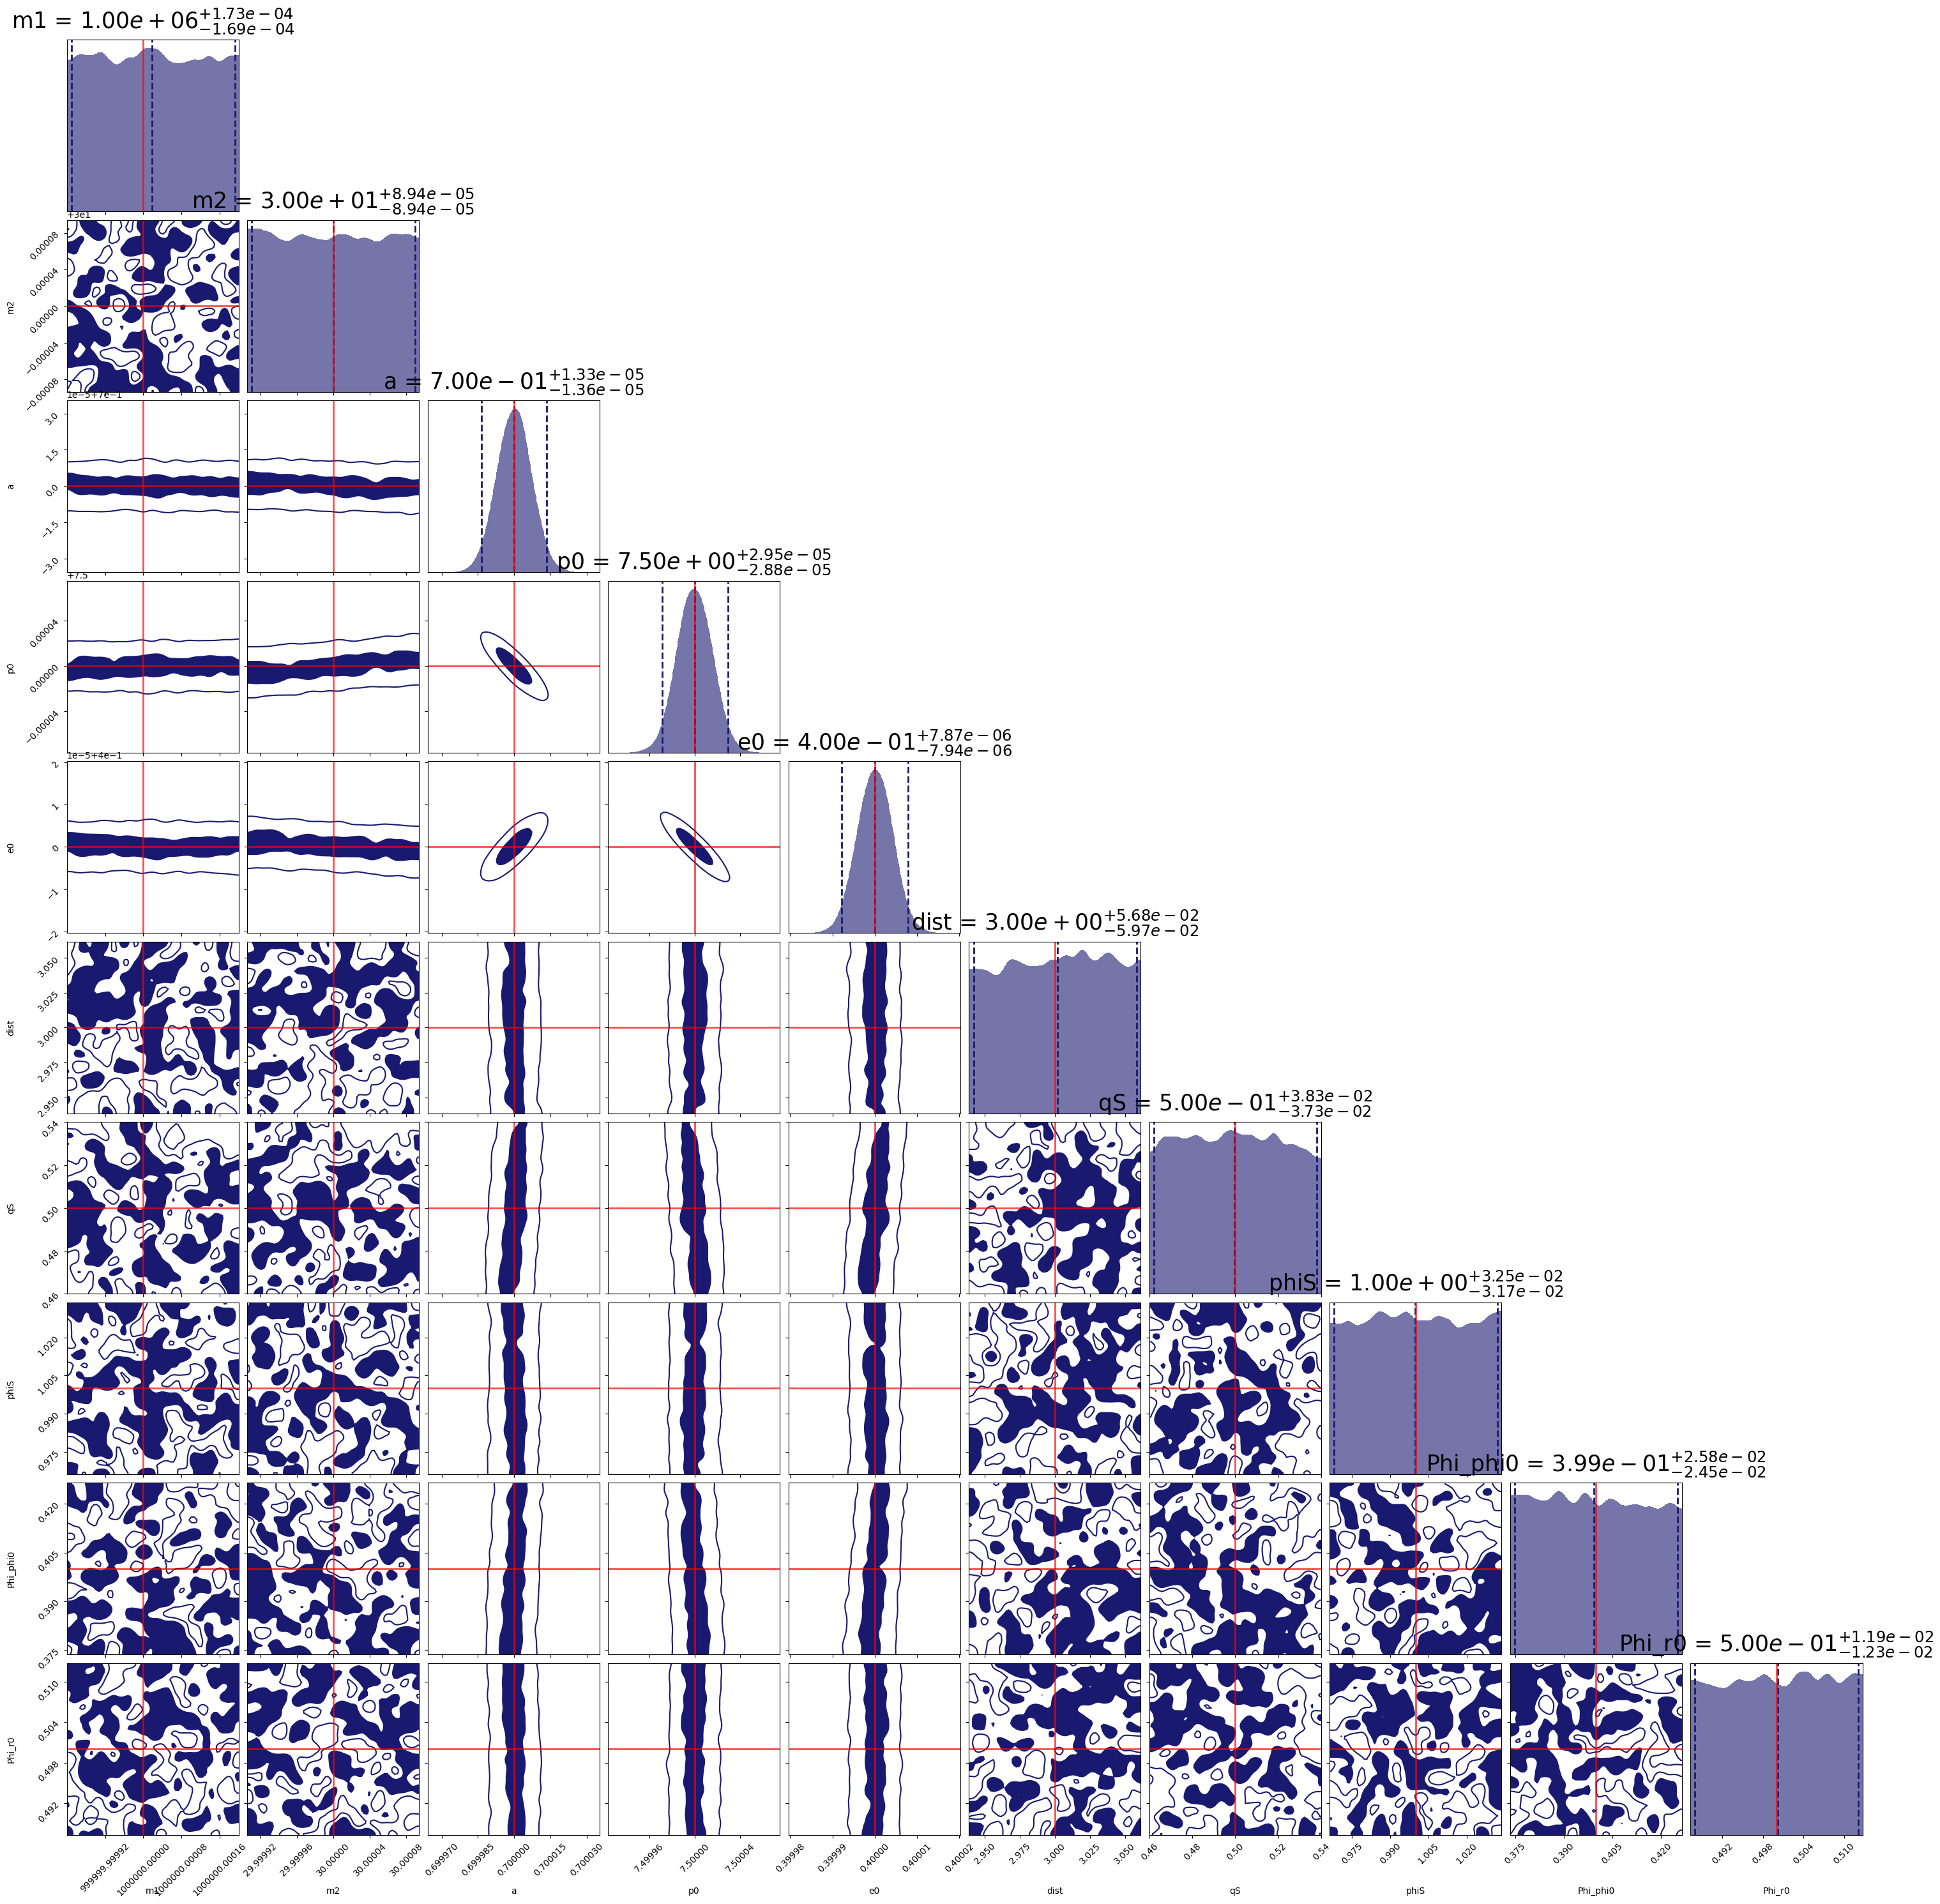

In [10]:
#cornerplot
from dynesty import plotting as dyplot
import matplotlib.pyplot as plt
fig, axes = dyplot.cornerplot(dres, show_titles=True, truth_color='red', smooth=0.03, color='midnightblue', quantiles_2d = [0.4, 0.85],
                              title_kwargs={'y': 1.04,'fontsize':25}, title_fmt='.2e',
                              fig=plt.subplots(ndim, ndim, figsize=(30, 30)), labels=labels, 
                              truths= [m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0])


In [11]:
dres

         niter: 29656
         ncall: array([1, 1, 1, ..., 1, 1, 1])
           eff: 4.026617822970567
       samples: array([[1.00000000e+06, 3.00000073e+01, 7.00018039e-01, ...,
        1.00494589e+00, 4.08915869e-01, 5.10338866e-01],
       [1.00000000e+06, 3.00000300e+01, 6.99985635e-01, ...,
        9.72624251e-01, 4.25901595e-01, 4.92587954e-01],
       [1.00000000e+06, 3.00000297e+01, 6.99982651e-01, ...,
        1.01239617e+00, 3.92333733e-01, 5.00486311e-01],
       ...,
       [1.00000000e+06, 2.99999582e+01, 7.00001294e-01, ...,
        1.02634084e+00, 4.10470782e-01, 4.90874064e-01],
       [1.00000000e+06, 2.99999119e+01, 6.99999917e-01, ...,
        9.67844906e-01, 3.97159626e-01, 5.07290325e-01],
       [1.00000000e+06, 3.00000580e+01, 7.00001018e-01, ...,
        1.00672905e+00, 4.13620265e-01, 4.94190636e-01]])
    samples_id: array([ 743, 1212,   10, ...,   78,  439,  249])
 samples_batch: array([0, 0, 0, ..., 0, 0, 0])
    samples_it: array([    0,     0,     0, ...,